In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
# Load dataset
df = pd.read_csv("size_trials4.csv", header=None)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print(X_scaled.shape)

# Apply PCA over all components to find contribution
pca = PCA(n_components=56)
pca.fit(X_scaled)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Print contribution of each principal component
for i, ratio in enumerate(explained_variance_ratio):
   print(f"Principal Component {i+1}: {ratio:.4f} ({ratio*100:.2f}% of total variance)")

(56, 892)
Principal Component 1: 0.2117 (21.17% of total variance)
Principal Component 2: 0.0467 (4.67% of total variance)
Principal Component 3: 0.0422 (4.22% of total variance)
Principal Component 4: 0.0353 (3.53% of total variance)
Principal Component 5: 0.0327 (3.27% of total variance)
Principal Component 6: 0.0268 (2.68% of total variance)
Principal Component 7: 0.0261 (2.61% of total variance)
Principal Component 8: 0.0235 (2.35% of total variance)
Principal Component 9: 0.0226 (2.26% of total variance)
Principal Component 10: 0.0210 (2.10% of total variance)
Principal Component 11: 0.0204 (2.04% of total variance)
Principal Component 12: 0.0198 (1.98% of total variance)
Principal Component 13: 0.0186 (1.86% of total variance)
Principal Component 14: 0.0179 (1.79% of total variance)
Principal Component 15: 0.0174 (1.74% of total variance)
Principal Component 16: 0.0172 (1.72% of total variance)
Principal Component 17: 0.0163 (1.63% of total variance)
Principal Component 18: 0.015

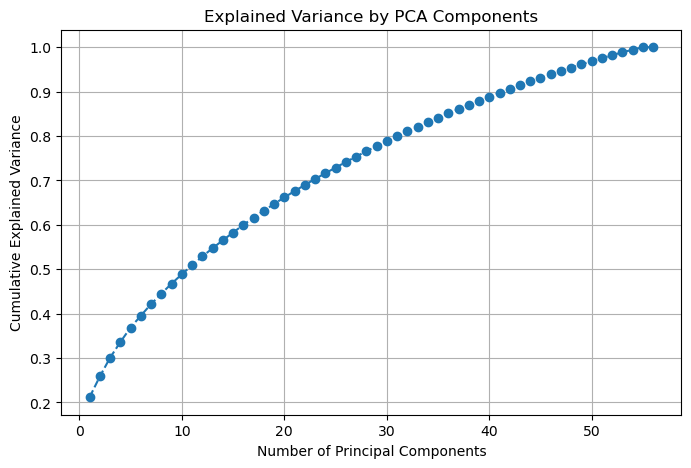

In [4]:
# Cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Scree plot
plt.figure(figsize=(8,5))
plt.plot(range(1, 57), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid()
plt.show()

In [5]:
# Reduce dimensions to 3D using PCA - accounts for > 60% of variance
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

### 3D Plot of Data Points

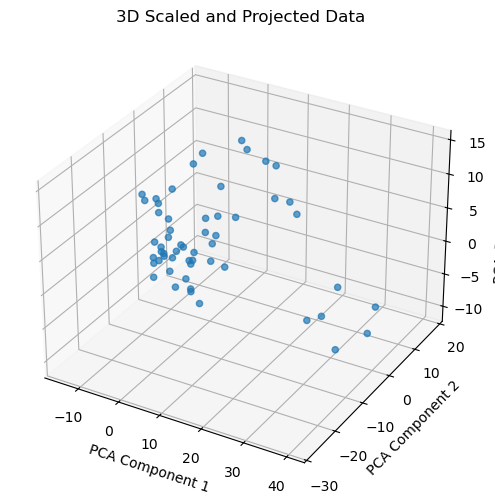

In [6]:
# 3D Plot of data points
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], alpha=0.7)

# Labels and title
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.set_title("3D Scaled and Projected Data")

plt.show()

### 2D Plot of Data Points

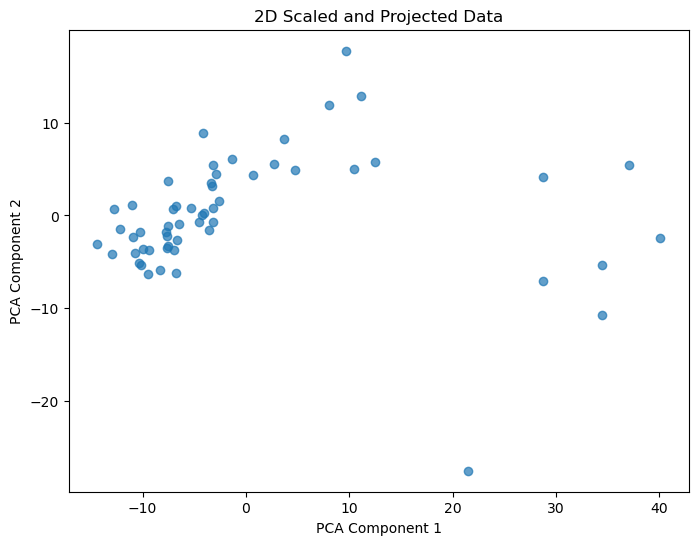

In [13]:
# 2D Plot of data points
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)

# Labels and title
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_title("2D Scaled and Projected Data")

plt.show()

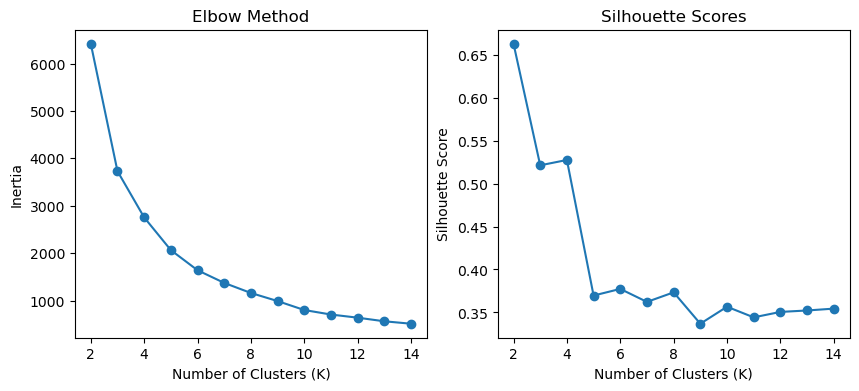

In [7]:
# Find optimal K using the Elbow Method
inertia = []
silhouette_scores = []
K_range = range(2, 15)  # Test clusters from 2 to 14

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')

plt.show()

In [8]:
# Choose the best K based on Elbow or Silhouette
optimal_k = 5  # Replace with your chosen K

# Fit K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_pca)

# Analyze cluster distribution
print(df['Cluster'].value_counts())

# Add cluster labels back to the original dataset
df.to_csv("clustered_data.csv", index=False)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_
print("Cluster labels:", labels.shape)
print("Centroids shape:", centroids.shape)
print(labels)
print(centroids)

Cluster
2    22
0    16
3    11
1     6
4     1
Name: count, dtype: int64
Cluster labels: (56,)
Centroids shape: (5, 3)
[1 3 0 0 0 2 2 2 1 3 0 0 0 0 2 0 1 3 3 2 0 2 2 2 1 3 0 0 2 0 0 0 1 3 3 0 2
 0 2 2 1 3 3 2 2 2 2 2 4 3 3 2 2 2 2 2]
[[-4.32475155e+00  2.01067899e+00 -4.54330553e+00]
 [ 3.39102788e+01 -2.64652317e+00 -4.62225480e+00]
 [-9.61464234e+00 -3.07513484e+00  2.18458429e-03]
 [ 5.07178309e+00  7.16746280e+00  7.80514879e+00]
 [ 2.14668692e+01 -2.74808493e+01  1.45217197e+01]]


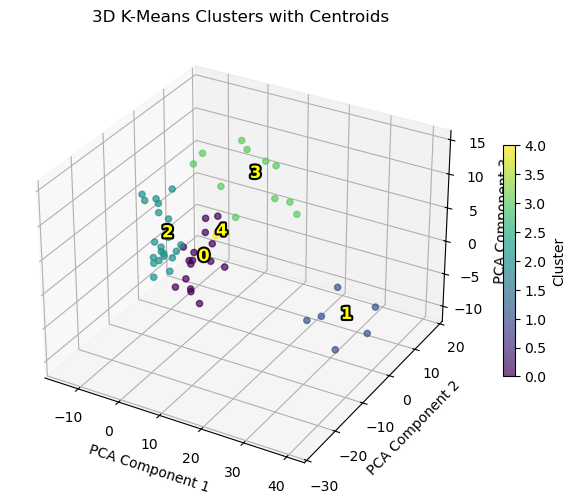

In [9]:
# 3D Plot of clusters with centroids
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot (invisible, to maintain scale on axes)
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=df['Cluster'], cmap='viridis', alpha=0.7, zorder=1, depthshade=False)

# Overlay centroids (bigger, red, distinct marker)
# ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], c='black', marker='X', s=200, edgecolors='black', label='Centroids', zorder=2)

# Add labels to the centroids with slight offsets to avoid overlap
# offsets = np.random.normal(0, 0.01, size=(optimal_k, 3))  # Small random offsets for spacing
for i in range(optimal_k):
    text = ax.text(centroids[i, 0], # + offsets[i, 0], 
            centroids[i, 1],        #  + offsets[i, 1], 
            centroids[i, 2],        #  + offsets[i, 2], 
            f'{i}', color='yellow', fontsize=12, weight='bold', zorder=3)

    # Add halo effect (black outline)
    text.set_path_effects([path_effects.Stroke(linewidth=3, foreground='black'), 
                            path_effects.Normal()])
    
# Labels and titled
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.set_title("3D K-Means Clusters with Centroids")

# Color bar
legend = plt.colorbar(scatter, ax=ax, shrink=0.5)
legend.set_label("Cluster")

plt.show()

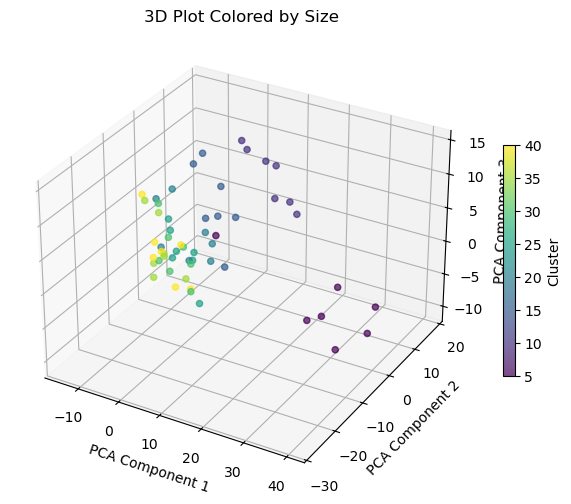

In [10]:
# 3D Plot of clusters colored by size
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

Sz = []
for i in range(56):
    Sz.append(((i%8)*5)+5)

df['Size'] = Sz

# Scatter plot (invisible, to maintain scale on axes)
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=df['Size'], cmap='viridis', alpha=0.7, zorder=1, depthshade=False)

# Labels and titled
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.set_title("3D Plot Colored by Size")

# Color bar
legend = plt.colorbar(scatter, ax=ax, shrink=0.5)
legend.set_label("Cluster")

plt.show()

### 2D Clusters with K-Means

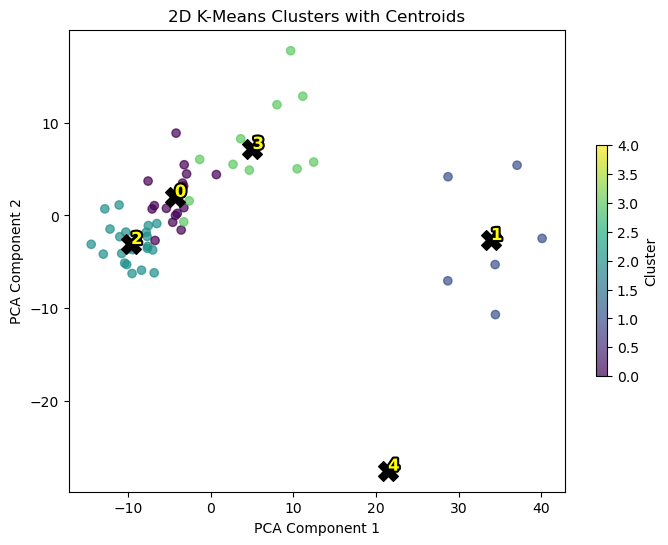

In [14]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 2D Plot of clusters with centroids
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot (invisible, to maintain scale on axes)
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis', alpha=0.7, zorder=1)

# Overlay centroids (bigger, red, distinct marker)
centroids_2d = centroids[:, :2]  # Take only the first two components for centroids in 2D
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1], c='black', marker='X', s=200, edgecolors='black', label='Centroids', zorder=2)

# Add labels to the centroids with slight offsets to avoid overlap
for i in range(optimal_k):
    text = ax.text(centroids_2d[i, 0], centroids_2d[i, 1], f'{i}', color='yellow', fontsize=12, weight='bold', zorder=3)

    # Add halo effect (black outline)
    text.set_path_effects([path_effects.Stroke(linewidth=3, foreground='black'), 
                            path_effects.Normal()])

# Labels and title
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_title("2D K-Means Clusters with Centroids")

# Color bar
legend = plt.colorbar(scatter, ax=ax, shrink=0.5)
legend.set_label("Cluster")

plt.show()


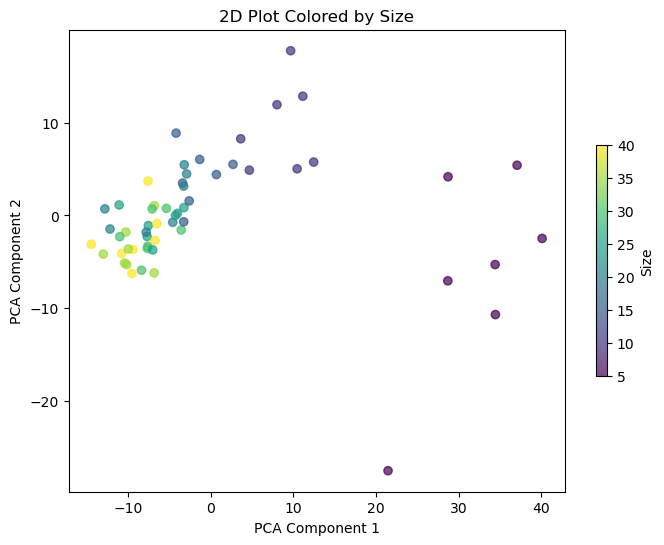

In [15]:
# 2D Plot of clusters colored by size
fig, ax = plt.subplots(figsize=(8, 6))

Sz = []
for i in range(56):
    Sz.append(((i % 8) * 5) + 5)

df['Size'] = Sz

# Scatter plot (invisible, to maintain scale on axes)
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Size'], cmap='viridis', alpha=0.7, zorder=1)

# Labels and title
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_title("2D Plot Colored by Size")

# Color bar
legend = plt.colorbar(scatter, ax=ax, shrink=0.5)
legend.set_label("Size")

plt.show()
